In [3]:
from google.colab import drive
import os

# 1. Ngắt kết nối Drive hiện tại (nếu có)
drive.flush_and_unmount()

# 2. Xóa sạch thư mục mount cũ để đảm bảo không bị lỗi "Already contains files"
!rm -rf /content/drive

# 3. Kết nối lại
drive.mount('/content/drive')

# 4. Kiểm tra lại đường dẫn
os.chdir('/content/drive/MyDrive/PROJECT')
print("Đã kết nối lại thành công tới:", os.getcwd())

shell-init: error retrieving current directory: getcwd: cannot access parent directories: Transport endpoint is not connected
Mounted at /content/drive
Đã kết nối lại thành công tới: /content/drive/MyDrive/PROJECT


# Notebook 4: MiniLM Ablation Study

Notebook này xây dựng và đánh giá nhóm mô hình gom cụm dựa trên biểu diễn ngữ nghĩa bằng MiniLM cho tập văn bản báo chí tiếng Việt.

Ở Notebook 3, bài làm đã xây dựng các baseline truyền thống dựa trên đặc trưng từ vựng như TF-IDF, BM25 và FP-Max. Tiếp nối cấu trúc đó, Notebook 4 tập trung vào nhóm mô hình hiện đại hơn, sử dụng embedding ngữ nghĩa để biểu diễn văn bản trước khi gom cụm bằng K-Means.

Mục tiêu chính của notebook:

- Tạo biểu diễn ngữ nghĩa cho văn bản bằng mô hình `paraphrase-multilingual-MiniLM-L12-v2`.
- Khảo sát các cấu hình biểu diễn khác nhau:
  - MiniLM gốc + K-Means
  - MiniLM + PCA + K-Means
  - MiniLM + UMAP + K-Means
- Khảo sát số cụm `k` trong khoảng từ 4 đến 10.
- Đánh giá chất lượng gom cụm bằng các chỉ số:
  - Silhouette Score
  - Davies-Bouldin Index
  - Calinski-Harabasz Index
  - Adjusted Rand Index
  - Normalized Mutual Information
  - Purity
- Chọn cấu hình MiniLM tốt nhất để làm semantic baseline cho các notebook tiếp theo.

Trong notebook này, các chỉ số ARI, NMI và Purity được dùng để đánh giá hậu nghiệm dựa trên nhãn chuyên mục có sẵn. Việc lựa chọn mô hình ưu tiên dựa trên các chỉ số nội tại như Silhouette Score, Davies-Bouldin Index và Calinski-Harabasz Index.

Kết quả của Notebook 4 sẽ được lưu lại để sử dụng trong Notebook 5 khi kiểm tra mô hình hybrid MiniLM + FP-Max và trong Notebook 6 khi tổng hợp, so sánh các mô hình.

In [4]:
# Cell 2: Import thư viện và khai báo đường dẫn

import pandas as pd
import numpy as np
import time
import json
import warnings
from pathlib import Path
from collections import Counter

import matplotlib.pyplot as plt

from sentence_transformers import SentenceTransformer

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.preprocessing import normalize
from sklearn.metrics import (
    normalized_mutual_info_score,
    adjusted_rand_score,
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

import umap

# Tắt warning phụ của Colab/Jupyter để output gọn hơn
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

# Đường dẫn project trên Google Drive
PROJECT_ROOT = Path("/content/drive/MyDrive/PROJECT")

DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"
OUTPUT_DIR = PROJECT_ROOT / "outputs"

RESULTS_DIR = OUTPUT_DIR / "results"
FEATURES_DIR = OUTPUT_DIR / "features"
ASSIGNMENTS_DIR = OUTPUT_DIR / "assignments"

# Chỉ tạo các thư mục thật sự cần cho Notebook 4
for folder in [RESULTS_DIR, FEATURES_DIR, ASSIGNMENTS_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

# File input từ Notebook 02
INPUT_PREPROCESSED = PROCESSED_DIR / "news_preprocessed.csv"

# File output chính của Notebook 04
OUTPUT_MINILM_EMBEDDINGS = FEATURES_DIR / "minilm_embeddings.npy"
OUTPUT_MINILM_ABLATION_RESULTS = RESULTS_DIR / "minilm_ablation_results.csv"
OUTPUT_BEST_MINILM_CONFIG = RESULTS_DIR / "best_minilm_config.json"
OUTPUT_MINILM_ASSIGNMENTS = ASSIGNMENTS_DIR / "minilm_cluster_assignments.csv"

RANDOM_STATE = 42

print("PROJECT_ROOT:", PROJECT_ROOT)
print("Input:", INPUT_PREPROCESSED)
print("Tồn tại:", INPUT_PREPROCESSED.exists())

print("\nOutput embeddings:", OUTPUT_MINILM_EMBEDDINGS)
print("Output ablation results:", OUTPUT_MINILM_ABLATION_RESULTS)
print("Output best config:", OUTPUT_BEST_MINILM_CONFIG)
print("Output assignments:", OUTPUT_MINILM_ASSIGNMENTS)

PROJECT_ROOT: /content/drive/MyDrive/PROJECT
Input: /content/drive/MyDrive/PROJECT/data/processed/news_preprocessed.csv
Tồn tại: True

Output embeddings: /content/drive/MyDrive/PROJECT/outputs/features/minilm_embeddings.npy
Output ablation results: /content/drive/MyDrive/PROJECT/outputs/results/minilm_ablation_results.csv
Output best config: /content/drive/MyDrive/PROJECT/outputs/results/best_minilm_config.json
Output assignments: /content/drive/MyDrive/PROJECT/outputs/assignments/minilm_cluster_assignments.csv


In [ ]:
# Cell 3: Đọc dữ liệu tiền xử lý và chuẩn bị văn bản cho nhánh semantic

df = pd.read_csv(INPUT_PREPROCESSED)

print("Kích thước dữ liệu:", df.shape)
print("\nCác cột hiện có:")
print(df.columns.tolist())

# Kiểm tra các cột bắt buộc
required_columns = ["doc_id", "category_clean", TEXT_COL]
missing_required = [col for col in required_columns if col not in df.columns]

if missing_required:
    raise ValueError(f"Thiếu các cột bắt buộc cho Notebook 4: {missing_required}")

# Tạo dữ liệu làm việc cho Notebook 4
df_work = df.copy()

df_work[TEXT_COL] = (
    df_work[TEXT_COL]
    .fillna("")
    .astype(str)
    .str.strip()
)

empty_text_count = (df_work[TEXT_COL] == "").sum()

print(f"\nCột văn bản dùng cho MiniLM: {TEXT_COL}")
print("Số dòng văn bản rỗng:", empty_text_count)

# Loại dòng rỗng nếu có
if empty_text_count > 0:
    df_work = df_work[df_work[TEXT_COL] != ""].copy()
    df_work = df_work.reset_index(drop=True)

print("Kích thước dữ liệu làm việc:", df_work.shape)

print("\nPhân bố chuyên mục:")
display(df_work["category_clean"].value_counts().to_frame("count"))

print("\nMột vài dòng dữ liệu đầu vào cho nhánh semantic:")
display(df_work[["doc_id", "category_clean", TEXT_COL]].head(3))

Kích thước dữ liệu: (8727, 14)

Các cột hiện có:
['doc_id', 'source', 'category_clean', 'title', 'description', 'content', 'published_date', 'url', 'raw_text', 'clean_text', 'segmented_text', 'lexical_text', 'semantic_text', 'word_count']

Cột văn bản dùng cho MiniLM: semantic_text
Số dòng văn bản rỗng: 0
Kích thước dữ liệu làm việc: (8727, 14)

Phân bố chuyên mục:


,count
category_clean,
du_lich,1979
giao_duc,1941
suc_khoe,1929
the_thao,1402
cong_nghe,991
xe,485



Một vài dòng dữ liệu đầu vào cho nhánh semantic:


,doc_id,category_clean,semantic_text
0,1,cong_nghe,"làn sóng máy tính lượng tử sau cơn sốt ai. quý 1-2026, thế giới chứng kiến loạt công ty vi tính lượng tử liên tiếp n..."
1,2,cong_nghe,"meta đưa ai vào messenger trả lời khách hàng 24/7. khách hàng nhắn tin lúc nửa đêm vẫn có người trả lời, khi meta tí..."
2,3,cong_nghe,"hà tiên sử dụng trí tuệ nhân tạo phục vụ hành chính công. ngày 10-4, ubnd phường hà tiên an giang ra mắt hệ thống ai..."


In [13]:
# Cell 4: Khai báo hàm đánh giá kết quả gom cụm

def purity_score(y_true, y_pred):
    """
    Tính Purity cho kết quả gom cụm.

    Purity đo mức độ mỗi cụm tập trung vào một nhãn chuyên mục chiếm đa số.
    Giá trị càng cao thì cụm càng thuần theo nhãn chuyên mục.
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    total_correct = 0

    for cluster_id in np.unique(y_pred):
        cluster_mask = y_pred == cluster_id
        labels_in_cluster = y_true[cluster_mask]

        if len(labels_in_cluster) == 0:
            continue

        most_common_count = Counter(labels_in_cluster).most_common(1)[0][1]
        total_correct += most_common_count

    return total_correct / len(y_true)


def cluster_size_info(labels):
    """
    Tính thông tin phân bố kích thước cụm để kiểm tra cụm có bị lệch quá không.
    """
    cluster_sizes = pd.Series(labels).value_counts().sort_index()

    return {
        "cluster_size_min": int(cluster_sizes.min()),
        "cluster_size_max": int(cluster_sizes.max()),
        "cluster_size_std": float(cluster_sizes.std())
    }


def run_kmeans_for_k_survey(
    X,
    model_name,
    reduction,
    n_components,
    k,
    seed=RANDOM_STATE
):
    """
    Chạy K-Means cho giai đoạn khảo sát k.

    Giai đoạn này chỉ dùng:
    - Inertia / Elbow
    - Silhouette
    - DBI
    - CH

    Chưa dùng ARI, NMI, Purity vì chưa chốt mô hình.
    """
    kmeans = KMeans(
        n_clusters=k,
        random_state=seed,
        n_init=20
    )

    labels = kmeans.fit_predict(X)

    result = {
        "model_name": model_name,
        "reduction": reduction,
        "n_components": n_components,
        "k": k,
        "seed": seed,
        "inertia": kmeans.inertia_,
        "silhouette": silhouette_score(X, labels),
        "dbi": davies_bouldin_score(X, labels),
        "ch": calinski_harabasz_score(X, labels)
    }

    result.update(cluster_size_info(labels))

    return result, labels


def run_kmeans_for_final_evaluation(
    X,
    y_true,
    model_name,
    reduction,
    n_components,
    k,
    seed=RANDOM_STATE
):
    """
    Chạy K-Means cho mô hình đã chốt.

    Giai đoạn này báo cáo đủ 6 chỉ số:
    - Silhouette
    - DBI
    - CH
    - ARI
    - NMI
    - Purity
    """
    kmeans = KMeans(
        n_clusters=k,
        random_state=seed,
        n_init=20
    )

    labels = kmeans.fit_predict(X)

    result = {
        "model_name": model_name,
        "reduction": reduction,
        "n_components": n_components,
        "k": k,
        "seed": seed,
        "inertia": kmeans.inertia_,
        "silhouette": silhouette_score(X, labels),
        "dbi": davies_bouldin_score(X, labels),
        "ch": calinski_harabasz_score(X, labels),
        "ari": adjusted_rand_score(y_true, labels),
        "nmi": normalized_mutual_info_score(y_true, labels),
        "purity": purity_score(y_true, labels)
    }

    result.update(cluster_size_info(labels))

    return result, labels


print("Đã khai báo xong các hàm khảo sát k và đánh giá mô hình chốt.")

Đã khai báo xong các hàm khảo sát k và đánh giá mô hình chốt.


In [8]:
# Cell 5: Tạo hoặc đọc lại MiniLM embeddings
# Cell này tạo embedding ngữ nghĩa từ semantic_text bằng MiniLM.
# Nếu file embedding đã tồn tại thì đọc lại để tránh encode lại mất thời gian.

import torch

MODEL_NAME = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Thiết bị đang dùng:", device)

# Văn bản đầu vào cho MiniLM
texts = df_work[TEXT_COL].tolist()
y_true = df_work["category_clean"].astype(str).values

print("Số văn bản cần encode:", len(texts))
print("Model sử dụng:", MODEL_NAME)

if OUTPUT_MINILM_EMBEDDINGS.exists():
    print("\nĐã tìm thấy file MiniLM embedding đã lưu. Đang tải lại...")
    X_minilm = np.load(OUTPUT_MINILM_EMBEDDINGS)

else:
    print("\nChưa có embedding. Đang tải model MiniLM...")
    model = SentenceTransformer(MODEL_NAME, device=device)

    print("Đang tạo MiniLM embeddings...")
    start_time = time.time()

    X_minilm = model.encode(
        texts,
        batch_size=32,
        show_progress_bar=True,
        convert_to_numpy=True,
        normalize_embeddings=False
    )

    elapsed_time = time.time() - start_time

    np.save(OUTPUT_MINILM_EMBEDDINGS, X_minilm)

    print(f"\nHoàn thành tạo embedding trong: {elapsed_time:.2f} giây")
    print("Đã lưu embedding tại:", OUTPUT_MINILM_EMBEDDINGS)

print("\nKích thước ma trận MiniLM embedding:", X_minilm.shape)
print("Kiểu dữ liệu:", X_minilm.dtype)
print("Có NaN không:", np.isnan(X_minilm).any())

Thiết bị đang dùng: cuda
Số văn bản cần encode: 8727
Model sử dụng: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2

Chưa có embedding. Đang tải model MiniLM...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/3.89k [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Đang tạo MiniLM embeddings...


Batches:   0%|          | 0/273 [00:00<?, ?it/s]


Hoàn thành tạo embedding trong: 26.62 giây
Đã lưu embedding tại: /content/drive/MyDrive/PROJECT/outputs/features/minilm_embeddings.npy

Kích thước ma trận MiniLM embedding: (8727, 384)
Kiểu dữ liệu: float32
Có NaN không: False


In [9]:
# Cell 6: Chuẩn hóa MiniLM embeddings
# Cell này chuẩn hóa L2 cho embedding MiniLM để phù hợp với K-Means và so sánh công bằng giữa các cấu hình.

X_minilm_norm = normalize(X_minilm)

print("Kích thước embedding gốc:", X_minilm.shape)
print("Kích thước embedding sau chuẩn hóa:", X_minilm_norm.shape)

# Kiểm tra norm của một vài vector đầu tiên
sample_norms = np.linalg.norm(X_minilm_norm[:5], axis=1)

print("Norm của 5 vector đầu sau chuẩn hóa:")
print(sample_norms)

print("Có NaN không:", np.isnan(X_minilm_norm).any())

Kích thước embedding gốc: (8727, 384)
Kích thước embedding sau chuẩn hóa: (8727, 384)
Norm của 5 vector đầu sau chuẩn hóa:
[1.         1.         0.99999994 1.         1.        ]
Có NaN không: False


Bắt đầu khảo sát k cho MiniLM raw + KMeans...
Hoàn thành khảo sát MiniLM raw trong: 68.33 giây


,model_name,reduction,n_components,k,inertia,silhouette,dbi,ch,cluster_size_min,cluster_size_max,cluster_size_std
0,MiniLM_raw,none,384,4,6246.134277,0.067320,3.414721,443.907532,1374,2850,652.863628
1,MiniLM_raw,none,384,5,6066.768066,0.074826,3.494190,407.200928,1352,1876,221.541870
2,MiniLM_raw,none,384,6,5975.099121,0.075421,3.499678,357.475494,994,1835,351.969175
3,MiniLM_raw,none,384,7,5888.645508,0.075762,3.537734,323.573639,685,1772,366.201090
4,MiniLM_raw,none,384,8,5809.863281,0.071165,3.507100,297.969391,666,1742,357.315562
5,MiniLM_raw,none,384,9,5740.333496,0.059330,3.586470,277.053619,649,1326,228.592979
6,MiniLM_raw,none,384,10,5679.819824,0.058346,3.555874,259.181641,577,1321,229.737556


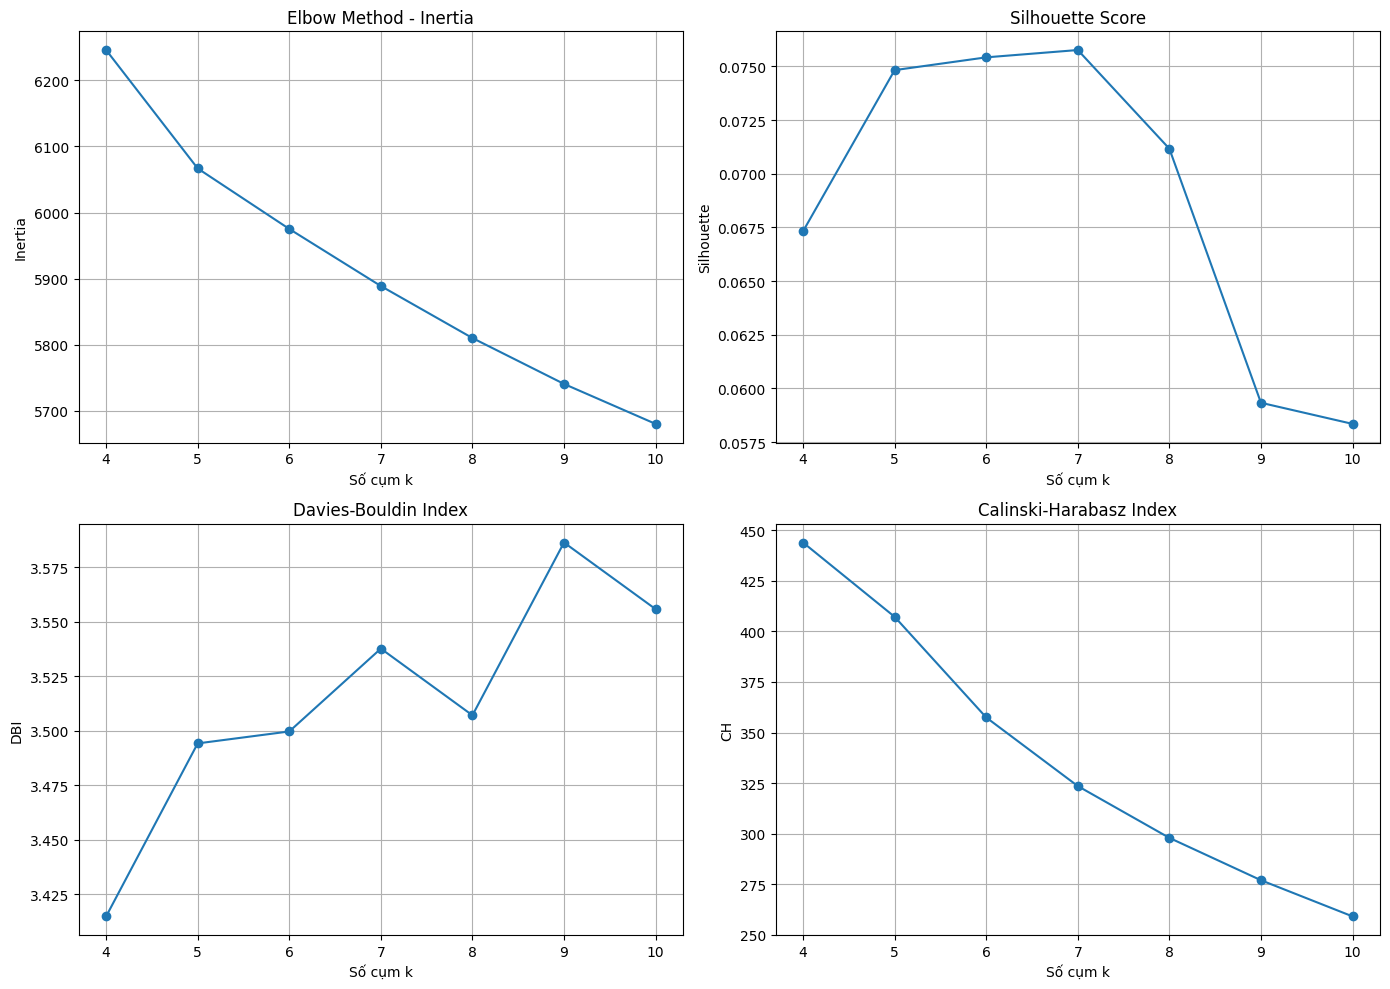

In [14]:
# Cell 7: Khảo sát k cho MiniLM raw + KMeans
# Cell này dùng MiniLM embedding đã chuẩn hóa và chạy KMeans với k từ 4 đến 10.
# Giai đoạn khảo sát k chỉ dùng Elbow/Inertia, Silhouette, DBI và CH giống cấu trúc Notebook 3.

k_values = list(range(4, 11))

raw_results = []

print("Bắt đầu khảo sát k cho MiniLM raw + KMeans...")
start_time = time.time()

for k in k_values:
    result, labels = run_kmeans_for_k_survey(
        X=X_minilm_norm,
        model_name="MiniLM_raw",
        reduction="none",
        n_components=X_minilm_norm.shape[1],
        k=k,
        seed=RANDOM_STATE
    )

    raw_results.append(result)

raw_results_df = pd.DataFrame(raw_results)

elapsed_time = time.time() - start_time

print(f"Hoàn thành khảo sát MiniLM raw trong: {elapsed_time:.2f} giây")

display(
    raw_results_df[
        [
            "model_name",
            "reduction",
            "n_components",
            "k",
            "inertia",
            "silhouette",
            "dbi",
            "ch",
            "cluster_size_min",
            "cluster_size_max",
            "cluster_size_std"
        ]
    ].sort_values("k")
)

# Vẽ biểu đồ khảo sát k cho MiniLM raw
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(raw_results_df["k"], raw_results_df["inertia"], marker="o")
axes[0, 0].set_title("Elbow Method - Inertia")
axes[0, 0].set_xlabel("Số cụm k")
axes[0, 0].set_ylabel("Inertia")

axes[0, 1].plot(raw_results_df["k"], raw_results_df["silhouette"], marker="o")
axes[0, 1].set_title("Silhouette Score")
axes[0, 1].set_xlabel("Số cụm k")
axes[0, 1].set_ylabel("Silhouette")

axes[1, 0].plot(raw_results_df["k"], raw_results_df["dbi"], marker="o")
axes[1, 0].set_title("Davies-Bouldin Index")
axes[1, 0].set_xlabel("Số cụm k")
axes[1, 0].set_ylabel("DBI")

axes[1, 1].plot(raw_results_df["k"], raw_results_df["ch"], marker="o")
axes[1, 1].set_title("Calinski-Harabasz Index")
axes[1, 1].set_xlabel("Số cụm k")
axes[1, 1].set_ylabel("CH")

plt.tight_layout()
plt.show()

### Nhận xét khảo sát MiniLM raw + K-Means

Kết quả khảo sát MiniLM raw cho thấy Silhouette đạt cao nhất tại `k = 7`, trong khi DBI và CH lại tốt hơn ở `k = 4`. Đường Elbow/Inertia giảm tương đối đều và chưa thể hiện điểm gãy thật rõ.

Điều này cho thấy khi sử dụng trực tiếp embedding MiniLM 384 chiều, K-Means chưa tạo được cấu trúc cụm thật sự rõ ràng. Vì vậy, các bước tiếp theo tiếp tục khảo sát thêm PCA và UMAP để kiểm tra liệu giảm chiều có giúp cụm tách tốt hơn hay không.

Bắt đầu khảo sát MiniLM + PCA + KMeans...

Đang chạy PCA với n_components = 50...
Tổng explained variance: 0.7339

Đang chạy PCA với n_components = 100...
Tổng explained variance: 0.8958

Đang chạy PCA với n_components = 200...
Tổng explained variance: 0.9854

Hoàn thành khảo sát MiniLM + PCA trong: 80.31 giây


,model_name,reduction,n_components,k,explained_variance,inertia,silhouette,dbi,ch,cluster_size_min,cluster_size_max,cluster_size_std
0,MiniLM_PCA,PCA,50,4,0.733898,4331.322754,0.096395,2.841958,639.440796,1373,2885,656.790872
1,MiniLM_PCA,PCA,50,5,0.733898,4152.567383,0.105591,2.879345,594.033264,1351,1875,221.906061
2,MiniLM_PCA,PCA,50,6,0.733898,4061.841309,0.103667,2.879315,524.738159,1015,1833,344.395557
3,MiniLM_PCA,PCA,50,7,0.733898,3976.537109,0.103745,2.895532,477.793823,690,1762,364.258935
4,MiniLM_PCA,PCA,50,8,0.733898,3899.286621,0.099680,2.876056,442.279602,670,1738,355.220027
5,MiniLM_PCA,PCA,50,9,0.733898,3831.231934,0.088591,2.952190,413.180573,651,1320,224.987222
6,MiniLM_PCA,PCA,50,10,0.733898,3772.858887,0.087860,2.925102,387.898529,576,1315,230.316232
7,MiniLM_PCA,PCA,100,4,0.895795,5496.222656,0.076864,3.209497,504.291168,1372,2719,634.717457
8,MiniLM_PCA,PCA,100,5,0.895795,5317.010742,0.084902,3.268666,464.418701,1351,1878,222.108757
9,MiniLM_PCA,PCA,100,6,0.895795,5225.645508,0.084733,3.276887,408.482819,1011,1837,347.216791


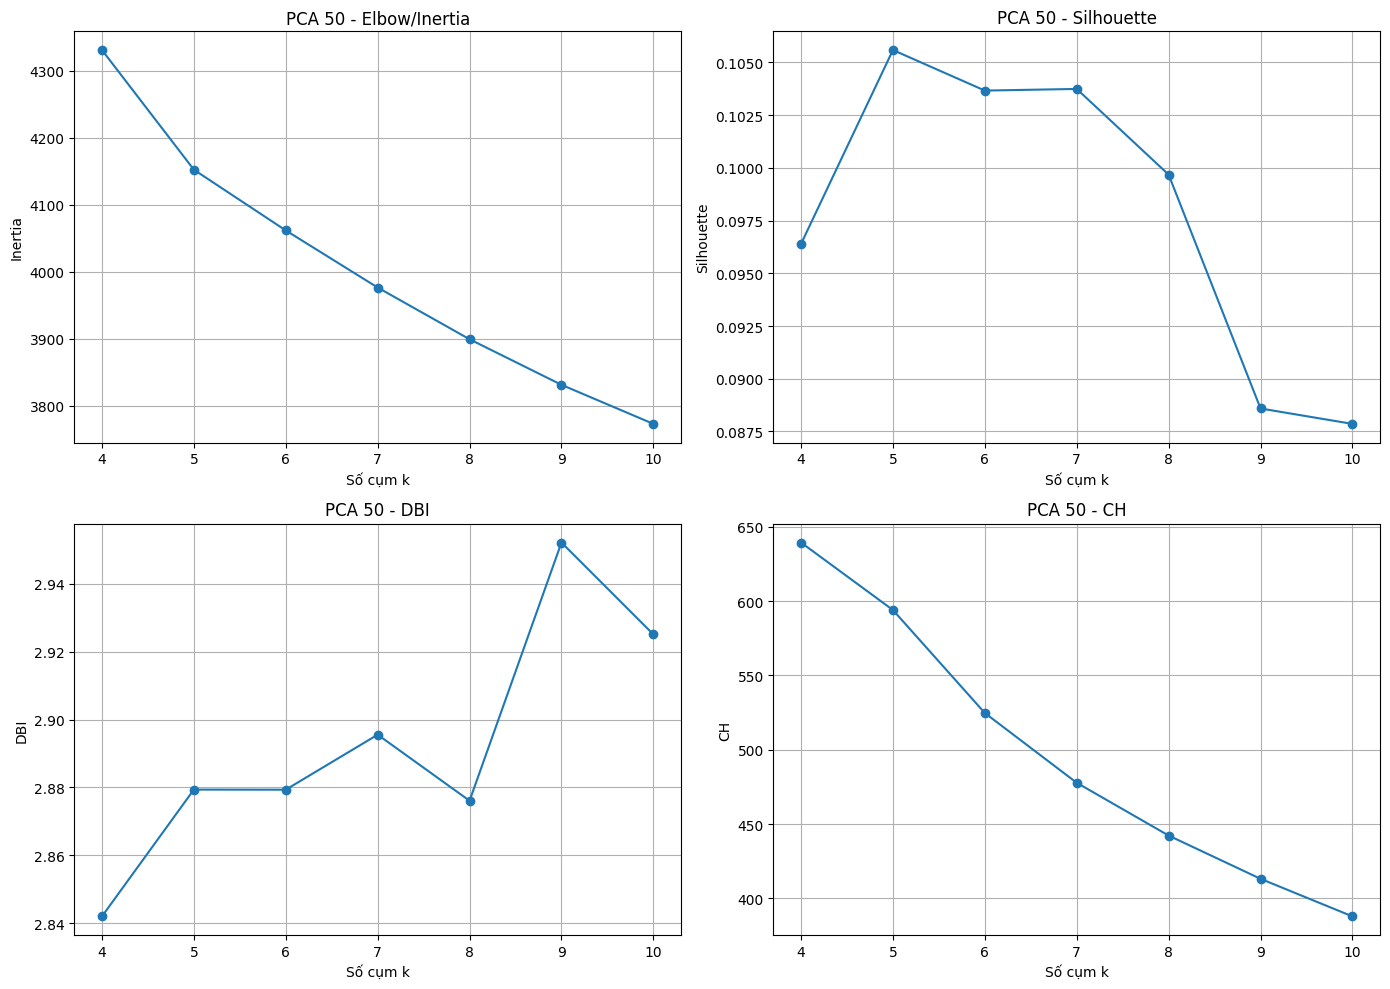

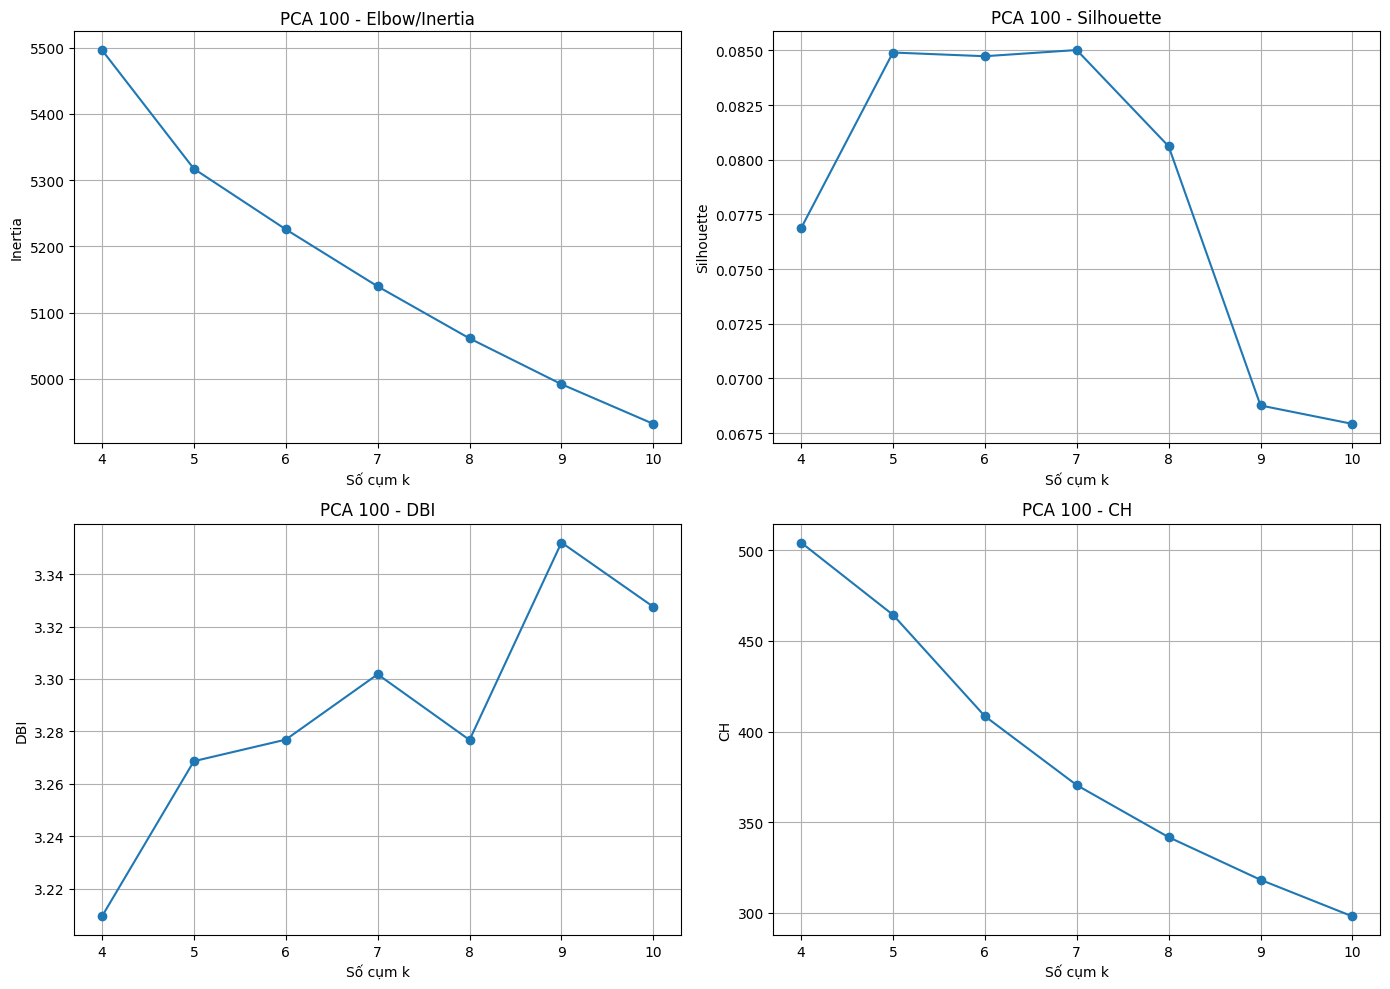

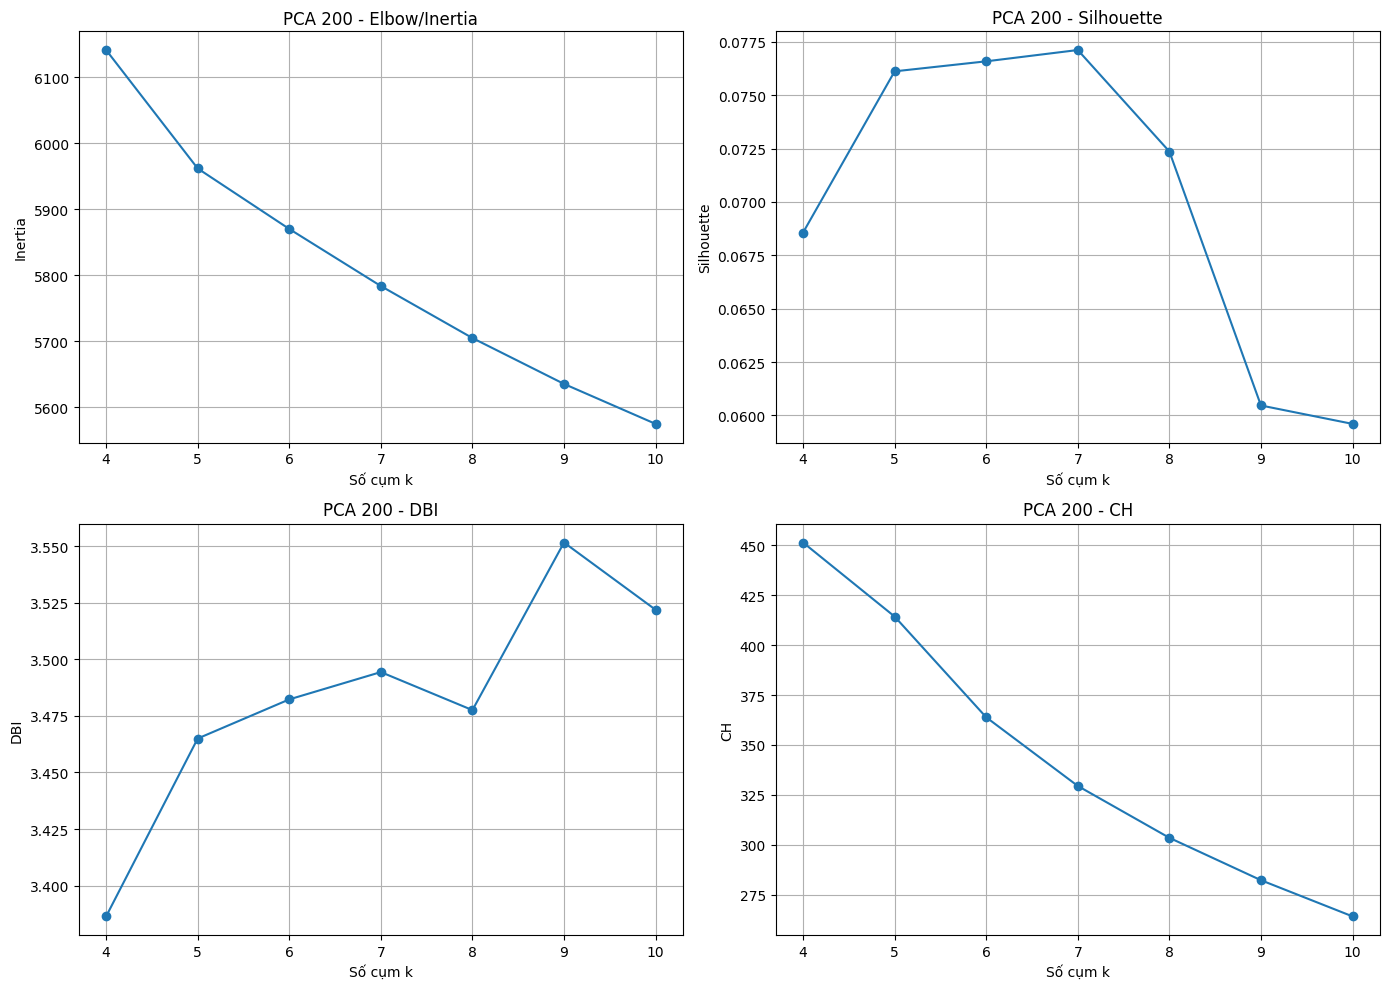

In [15]:
# Cell 8: Khảo sát MiniLM + PCA + KMeans
# Cell này giảm chiều MiniLM embedding bằng PCA với nhiều số chiều khác nhau,
# sau đó khảo sát k bằng Inertia, Silhouette, DBI và CH.

pca_components_list = [50, 100, 200]
pca_results = []

print("Bắt đầu khảo sát MiniLM + PCA + KMeans...")
start_time = time.time()

for n_components in pca_components_list:
    print(f"\nĐang chạy PCA với n_components = {n_components}...")

    pca = PCA(
        n_components=n_components,
        random_state=RANDOM_STATE
    )

    X_pca = pca.fit_transform(X_minilm_norm)

    explained_variance = pca.explained_variance_ratio_.sum()
    print(f"Tổng explained variance: {explained_variance:.4f}")

    for k in k_values:
        result, labels = run_kmeans_for_k_survey(
            X=X_pca,
            model_name="MiniLM_PCA",
            reduction="PCA",
            n_components=n_components,
            k=k,
            seed=RANDOM_STATE
        )

        result["explained_variance"] = explained_variance
        pca_results.append(result)

pca_results_df = pd.DataFrame(pca_results)

elapsed_time = time.time() - start_time
print(f"\nHoàn thành khảo sát MiniLM + PCA trong: {elapsed_time:.2f} giây")

display(
    pca_results_df[
        [
            "model_name",
            "reduction",
            "n_components",
            "k",
            "explained_variance",
            "inertia",
            "silhouette",
            "dbi",
            "ch",
            "cluster_size_min",
            "cluster_size_max",
            "cluster_size_std"
        ]
    ].sort_values(["n_components", "k"])
)

# Vẽ biểu đồ khảo sát k cho từng cấu hình PCA
for n_components in pca_components_list:
    temp_df = pca_results_df[pca_results_df["n_components"] == n_components]

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    axes[0, 0].plot(temp_df["k"], temp_df["inertia"], marker="o")
    axes[0, 0].set_title(f"PCA {n_components} - Elbow/Inertia")
    axes[0, 0].set_xlabel("Số cụm k")
    axes[0, 0].set_ylabel("Inertia")

    axes[0, 1].plot(temp_df["k"], temp_df["silhouette"], marker="o")
    axes[0, 1].set_title(f"PCA {n_components} - Silhouette")
    axes[0, 1].set_xlabel("Số cụm k")
    axes[0, 1].set_ylabel("Silhouette")

    axes[1, 0].plot(temp_df["k"], temp_df["dbi"], marker="o")
    axes[1, 0].set_title(f"PCA {n_components} - DBI")
    axes[1, 0].set_xlabel("Số cụm k")
    axes[1, 0].set_ylabel("DBI")

    axes[1, 1].plot(temp_df["k"], temp_df["ch"], marker="o")
    axes[1, 1].set_title(f"PCA {n_components} - CH")
    axes[1, 1].set_xlabel("Số cụm k")
    axes[1, 1].set_ylabel("CH")

    plt.tight_layout()
    plt.show()

### Nhận xét khảo sát MiniLM + PCA + K-Means

Kết quả khảo sát cho thấy PCA giúp cải thiện chất lượng gom cụm so với MiniLM raw. Trong các cấu hình PCA, `PCA 50` cho kết quả tốt nhất, với Silhouette cao hơn, DBI thấp hơn và CH cao hơn so với PCA 100 và PCA 200.

Cụ thể, `PCA 50` đạt Silhouette cao nhất tại `k = 5`, trong khi DBI và CH tốt hơn ở `k = 4`. Điều này cho thấy PCA 50 giúp loại bỏ một phần nhiễu trong embedding gốc, làm cấu trúc cụm rõ hơn khi dùng K-Means.

Tuy nhiên, Notebook 4 chưa chốt mô hình tại bước này vì vẫn cần tiếp tục khảo sát UMAP để so sánh với PCA và MiniLM raw trên cùng tiêu chí.

Bắt đầu khảo sát MiniLM + UMAP + KMeans...

Đang chạy UMAP với n_components = 20...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Kích thước sau UMAP: (8727, 20)

Đang chạy UMAP với n_components = 50...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Kích thước sau UMAP: (8727, 50)

Đang chạy UMAP với n_components = 100...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Kích thước sau UMAP: (8727, 100)

Hoàn thành khảo sát MiniLM + UMAP trong: 210.38 giây


,model_name,reduction,n_components,k,inertia,silhouette,dbi,ch,cluster_size_min,cluster_size_max,cluster_size_std
0,MiniLM_UMAP,UMAP,20,4,19239.869141,0.658688,0.489249,25361.775391,1398,2808,622.927698
1,MiniLM_UMAP,UMAP,20,5,15246.576172,0.625373,0.547835,24571.660156,598,2808,816.693210
2,MiniLM_UMAP,UMAP,20,6,11520.985352,0.582620,0.597492,26575.039062,598,1991,576.547570
3,MiniLM_UMAP,UMAP,20,7,10080.889648,0.534864,0.712855,25514.240234,597,1938,549.385328
4,MiniLM_UMAP,UMAP,20,8,8746.642578,0.495700,0.802661,25392.480469,576,1851,427.692292
5,MiniLM_UMAP,UMAP,20,9,7861.728027,0.509196,0.779824,24839.185547,522,1864,428.732434
6,MiniLM_UMAP,UMAP,20,10,7209.136230,0.465945,0.865503,24163.210938,522,1324,288.612408
7,MiniLM_UMAP,UMAP,50,4,19558.210938,0.652989,0.498590,24432.410156,1468,2812,584.210222
8,MiniLM_UMAP,UMAP,50,5,15476.903320,0.625387,0.544831,23728.841797,590,2812,811.584130
9,MiniLM_UMAP,UMAP,50,6,11586.388672,0.586870,0.588762,25940.046875,590,1985,567.212394


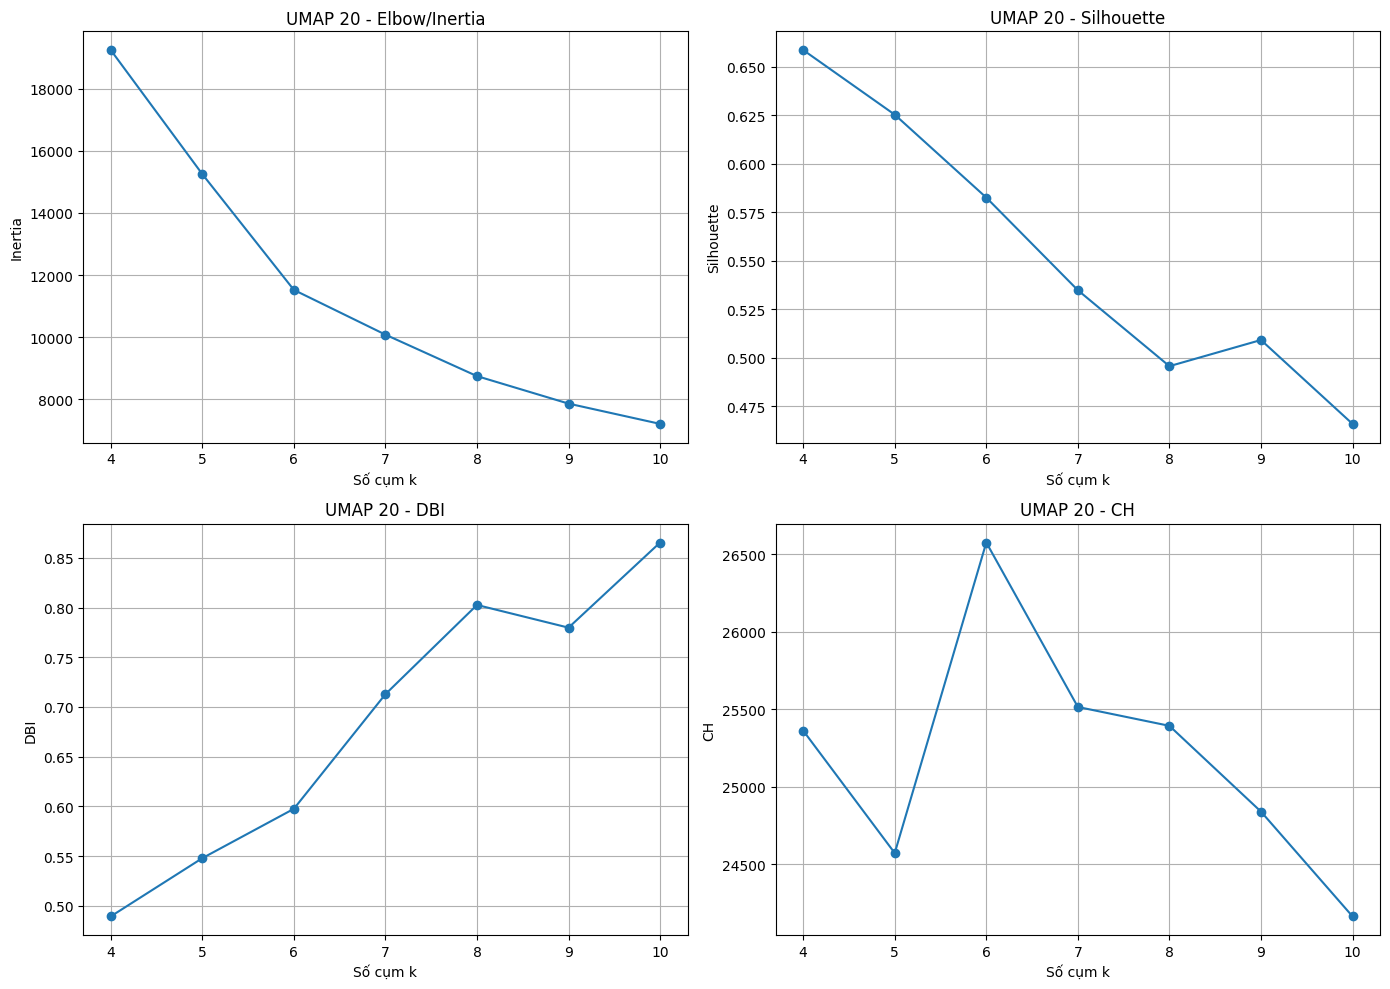

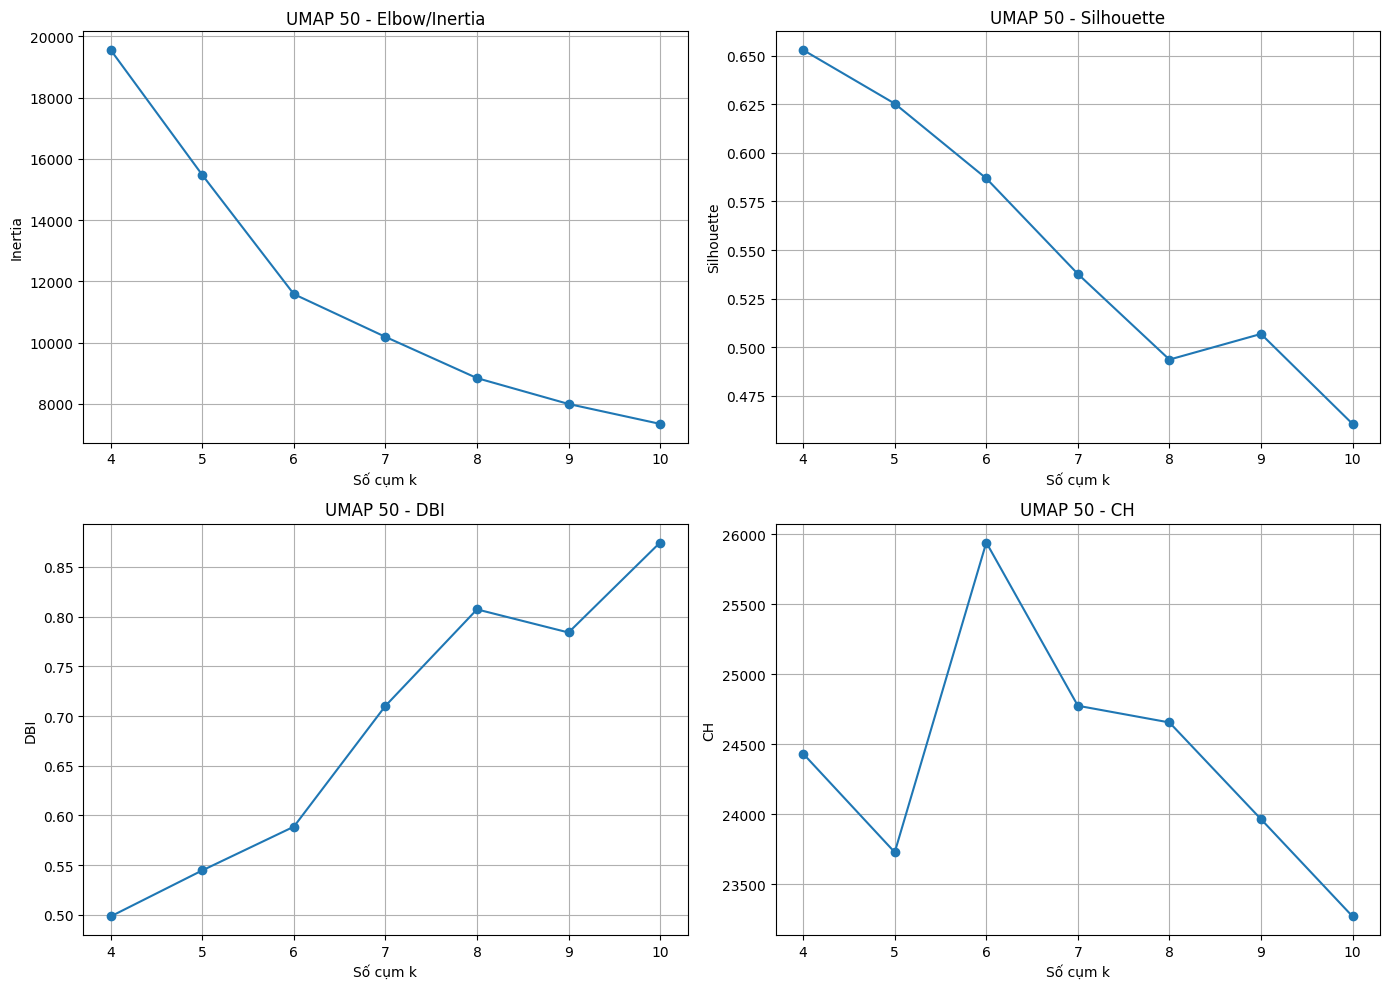

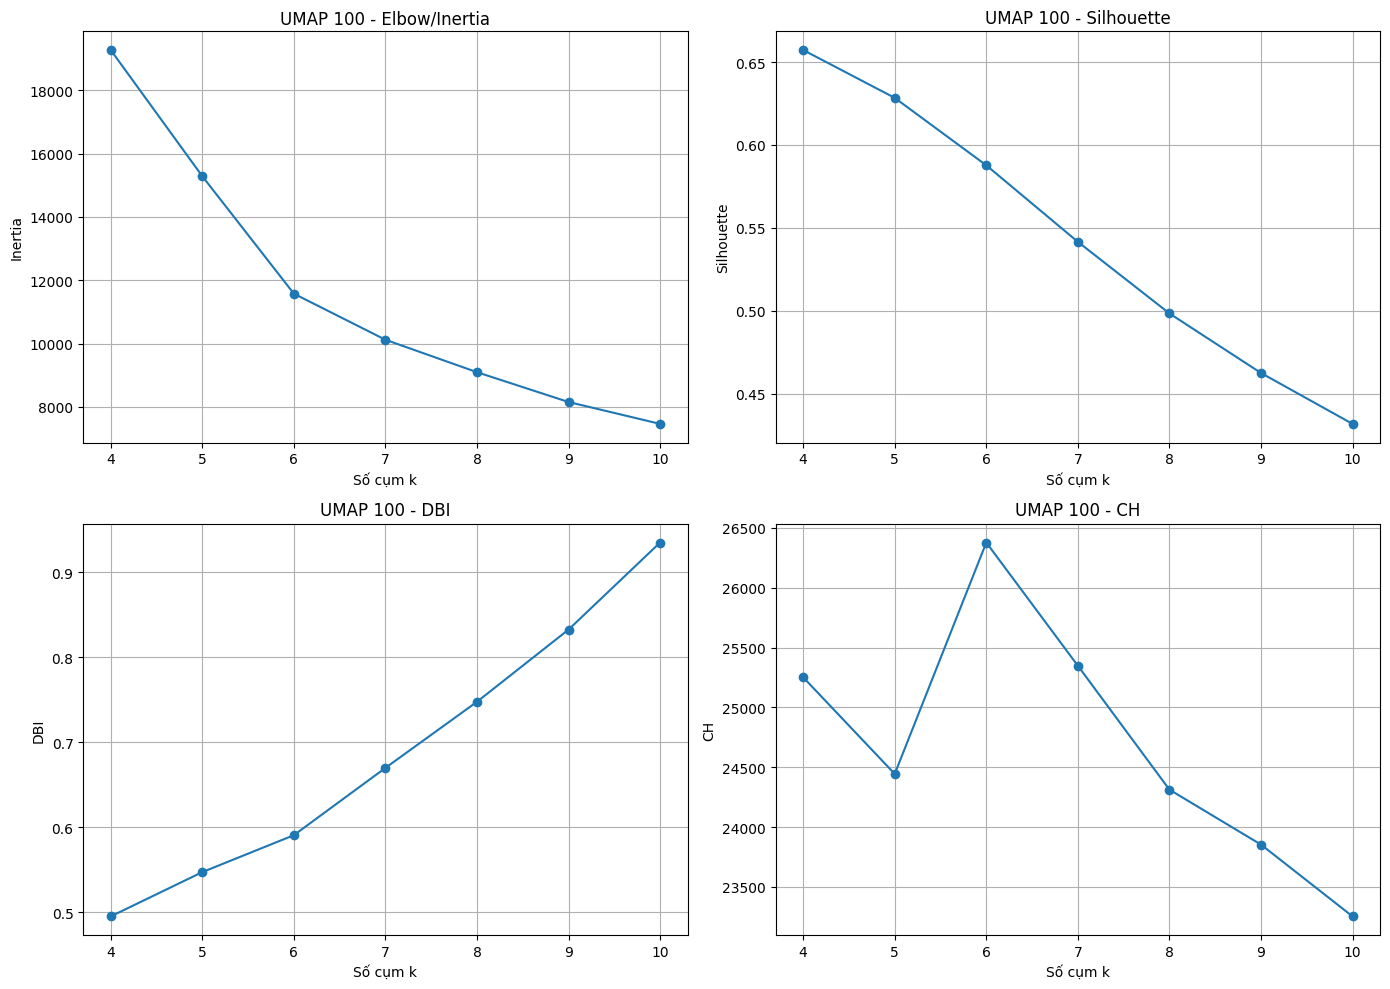

In [16]:
# Cell 9: Khảo sát MiniLM + UMAP + KMeans
# Cell này giảm chiều MiniLM embedding bằng UMAP với nhiều số chiều khác nhau,
# sau đó khảo sát k bằng Inertia, Silhouette, DBI và CH.

umap_components_list = [20, 50, 100]
umap_results = []

print("Bắt đầu khảo sát MiniLM + UMAP + KMeans...")
start_time = time.time()

for n_components in umap_components_list:
    print(f"\nĐang chạy UMAP với n_components = {n_components}...")

    umap_reducer = umap.UMAP(
        n_neighbors=15,
        n_components=n_components,
        min_dist=0.0,
        metric="cosine",
        random_state=RANDOM_STATE
    )

    X_umap = umap_reducer.fit_transform(X_minilm_norm)

    print("Kích thước sau UMAP:", X_umap.shape)

    for k in k_values:
        result, _ = run_kmeans_for_k_survey(
            X=X_umap,
            model_name="MiniLM_UMAP",
            reduction="UMAP",
            n_components=n_components,
            k=k,
            seed=RANDOM_STATE
        )

        umap_results.append(result)

umap_results_df = pd.DataFrame(umap_results)

elapsed_time = time.time() - start_time
print(f"\nHoàn thành khảo sát MiniLM + UMAP trong: {elapsed_time:.2f} giây")

display(
    umap_results_df[
        [
            "model_name",
            "reduction",
            "n_components",
            "k",
            "inertia",
            "silhouette",
            "dbi",
            "ch",
            "cluster_size_min",
            "cluster_size_max",
            "cluster_size_std"
        ]
    ].sort_values(["n_components", "k"])
)

# Vẽ biểu đồ khảo sát k cho từng cấu hình UMAP
for n_components in umap_components_list:
    temp_df = umap_results_df[umap_results_df["n_components"] == n_components]

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    axes[0, 0].plot(temp_df["k"], temp_df["inertia"], marker="o")
    axes[0, 0].set_title(f"UMAP {n_components} - Elbow/Inertia")
    axes[0, 0].set_xlabel("Số cụm k")
    axes[0, 0].set_ylabel("Inertia")

    axes[0, 1].plot(temp_df["k"], temp_df["silhouette"], marker="o")
    axes[0, 1].set_title(f"UMAP {n_components} - Silhouette")
    axes[0, 1].set_xlabel("Số cụm k")
    axes[0, 1].set_ylabel("Silhouette")

    axes[1, 0].plot(temp_df["k"], temp_df["dbi"], marker="o")
    axes[1, 0].set_title(f"UMAP {n_components} - DBI")
    axes[1, 0].set_xlabel("Số cụm k")
    axes[1, 0].set_ylabel("DBI")

    axes[1, 1].plot(temp_df["k"], temp_df["ch"], marker="o")
    axes[1, 1].set_title(f"UMAP {n_components} - CH")
    axes[1, 1].set_xlabel("Số cụm k")
    axes[1, 1].set_ylabel("CH")

    plt.tight_layout()
    plt.show()

In [17]:
# Cell 10: Tổng hợp kết quả ablation và chọn cấu hình ứng viên
# Cell này gộp kết quả MiniLM raw, PCA và UMAP để so sánh trên cùng một bảng.
# Mục tiêu là chọn một số cấu hình ứng viên hợp lý trước khi kiểm tra độ ổn định nhiều seed.

ablation_results_df = pd.concat(
    [
        raw_results_df,
        pca_results_df,
        umap_results_df
    ],
    ignore_index=True
)

# Nếu cấu hình không có explained_variance thì để NaN
if "explained_variance" not in ablation_results_df.columns:
    ablation_results_df["explained_variance"] = np.nan

display_columns = [
    "model_name",
    "reduction",
    "n_components",
    "k",
    "explained_variance",
    "inertia",
    "silhouette",
    "dbi",
    "ch",
    "cluster_size_min",
    "cluster_size_max",
    "cluster_size_std"
]

print("Kích thước bảng ablation:", ablation_results_df.shape)

print("\nTop 15 cấu hình theo Silhouette cao nhất:")
display(
    ablation_results_df[display_columns]
    .sort_values(["silhouette", "dbi"], ascending=[False, True])
    .head(15)
)

print("\nTop 15 cấu hình theo DBI thấp nhất:")
display(
    ablation_results_df[display_columns]
    .sort_values(["dbi", "silhouette"], ascending=[True, False])
    .head(15)
)

# Chọn ứng viên 1: cấu hình tốt nhất theo chỉ số nội tại, ưu tiên Silhouette cao và DBI thấp
best_internal_candidate = (
    ablation_results_df
    .sort_values(["silhouette", "dbi", "ch"], ascending=[False, True, False])
    .iloc[0]
)

# Chọn ứng viên 2: cấu hình tốt nhất trong nhóm k = 6
# Vì dữ liệu gốc có 6 chuyên mục, k = 6 vẫn cần được xem xét để phục vụ diễn giải.
k6_candidates = ablation_results_df[ablation_results_df["k"] == 6].copy()

k6_candidates["rank_silhouette"] = k6_candidates["silhouette"].rank(ascending=False)
k6_candidates["rank_dbi"] = k6_candidates["dbi"].rank(ascending=True)
k6_candidates["rank_ch"] = k6_candidates["ch"].rank(ascending=False)

k6_candidates["rank_score"] = (
    k6_candidates["rank_silhouette"]
    + k6_candidates["rank_dbi"]
    + k6_candidates["rank_ch"]
)

best_k6_candidate = (
    k6_candidates
    .sort_values(["rank_score", "silhouette", "dbi"], ascending=[True, False, True])
    .iloc[0]
)

candidate_configs_df = pd.DataFrame([
    best_internal_candidate[display_columns],
    best_k6_candidate[display_columns]
]).drop_duplicates(
    subset=["model_name", "reduction", "n_components", "k"]
).reset_index(drop=True)

print("\nCác cấu hình ứng viên được chọn để kiểm tra stability:")
display(candidate_configs_df)

Kích thước bảng ablation: (49, 13)

Top 15 cấu hình theo Silhouette cao nhất:


,model_name,reduction,n_components,k,explained_variance,inertia,silhouette,dbi,ch,cluster_size_min,cluster_size_max,cluster_size_std
28,MiniLM_UMAP,UMAP,20,4,NaN,19239.869141,0.658688,0.489249,25361.775391,1398,2808,622.927698
42,MiniLM_UMAP,UMAP,100,4,NaN,19268.716797,0.657271,0.495015,25251.160156,1465,2810,581.003944
35,MiniLM_UMAP,UMAP,50,4,NaN,19558.210938,0.652989,0.498590,24432.410156,1468,2812,584.210222
43,MiniLM_UMAP,UMAP,100,5,NaN,15282.793945,0.628396,0.547132,24443.687500,591,2810,809.965308
36,MiniLM_UMAP,UMAP,50,5,NaN,15476.903320,0.625387,0.544831,23728.841797,590,2812,811.584130
29,MiniLM_UMAP,UMAP,20,5,NaN,15246.576172,0.625373,0.547835,24571.660156,598,2808,816.693210
44,MiniLM_UMAP,UMAP,100,6,NaN,11573.898438,0.587704,0.590604,26377.453125,591,2002,575.605681
37,MiniLM_UMAP,UMAP,50,6,NaN,11586.388672,0.586870,0.588762,25940.046875,590,1985,567.212394
30,MiniLM_UMAP,UMAP,20,6,NaN,11520.985352,0.582620,0.597492,26575.039062,598,1991,576.547570
45,MiniLM_UMAP,UMAP,100,7,NaN,10119.000977,0.541532,0.669803,25347.630859,554,1875,562.457617



Top 15 cấu hình theo DBI thấp nhất:


,model_name,reduction,n_components,k,explained_variance,inertia,silhouette,dbi,ch,cluster_size_min,cluster_size_max,cluster_size_std
28,MiniLM_UMAP,UMAP,20,4,NaN,19239.869141,0.658688,0.489249,25361.775391,1398,2808,622.927698
42,MiniLM_UMAP,UMAP,100,4,NaN,19268.716797,0.657271,0.495015,25251.160156,1465,2810,581.003944
35,MiniLM_UMAP,UMAP,50,4,NaN,19558.210938,0.652989,0.498590,24432.410156,1468,2812,584.210222
36,MiniLM_UMAP,UMAP,50,5,NaN,15476.903320,0.625387,0.544831,23728.841797,590,2812,811.584130
43,MiniLM_UMAP,UMAP,100,5,NaN,15282.793945,0.628396,0.547132,24443.687500,591,2810,809.965308
29,MiniLM_UMAP,UMAP,20,5,NaN,15246.576172,0.625373,0.547835,24571.660156,598,2808,816.693210
37,MiniLM_UMAP,UMAP,50,6,NaN,11586.388672,0.586870,0.588762,25940.046875,590,1985,567.212394
44,MiniLM_UMAP,UMAP,100,6,NaN,11573.898438,0.587704,0.590604,26377.453125,591,2002,575.605681
30,MiniLM_UMAP,UMAP,20,6,NaN,11520.985352,0.582620,0.597492,26575.039062,598,1991,576.547570
45,MiniLM_UMAP,UMAP,100,7,NaN,10119.000977,0.541532,0.669803,25347.630859,554,1875,562.457617



Các cấu hình ứng viên được chọn để kiểm tra stability:


,model_name,reduction,n_components,k,explained_variance,inertia,silhouette,dbi,ch,cluster_size_min,cluster_size_max,cluster_size_std
0,MiniLM_UMAP,UMAP,20,4,NaN,19239.869141,0.658688,0.489249,25361.775391,1398,2808,622.927698
1,MiniLM_UMAP,UMAP,100,6,NaN,11573.898438,0.587704,0.590604,26377.453125,591,2002,575.605681


In [18]:
# Cell 11: Stability test cho các cấu hình MiniLM ứng viên
# Cell này kiểm tra độ ổn định của các cấu hình ứng viên qua nhiều random seed.
# Ở bước này, mô hình đã là ứng viên gần-final nên báo cáo đủ 6 chỉ số:
# Silhouette, DBI, CH, ARI, NMI và Purity.

stability_seeds = [0, 1, 7, 21, 42]
stability_results = []

print("Bắt đầu stability test cho các cấu hình ứng viên...")
start_time = time.time()

for _, candidate in candidate_configs_df.iterrows():
    reduction = candidate["reduction"]
    n_components = int(candidate["n_components"])
    k = int(candidate["k"])

    print(f"\nCấu hình ứng viên: {reduction} {n_components}, k = {k}")

    for seed in stability_seeds:
        print(f"  Đang chạy seed = {seed}...")

        if reduction == "UMAP":
            reducer = umap.UMAP(
                n_neighbors=15,
                n_components=n_components,
                min_dist=0.0,
                metric="cosine",
                random_state=seed
            )

            X_candidate = reducer.fit_transform(X_minilm_norm)

        elif reduction == "PCA":
            reducer = PCA(
                n_components=n_components,
                random_state=seed
            )

            X_candidate = reducer.fit_transform(X_minilm_norm)

        elif reduction == "none":
            X_candidate = X_minilm_norm

        else:
            raise ValueError(f"Reduction không hợp lệ: {reduction}")

        result, labels = run_kmeans_for_final_evaluation(
            X=X_candidate,
            y_true=y_true,
            model_name="MiniLM_" + reduction,
            reduction=reduction,
            n_components=n_components,
            k=k,
            seed=seed
        )

        stability_results.append(result)

stability_results_df = pd.DataFrame(stability_results)

elapsed_time = time.time() - start_time
print(f"\nHoàn thành stability test trong: {elapsed_time:.2f} giây")

display(
    stability_results_df[
        [
            "model_name",
            "reduction",
            "n_components",
            "k",
            "seed",
            "silhouette",
            "dbi",
            "ch",
            "ari",
            "nmi",
            "purity",
            "cluster_size_min",
            "cluster_size_max",
            "cluster_size_std"
        ]
    ].sort_values(["k", "n_components", "seed"])
)

Bắt đầu stability test cho các cấu hình ứng viên...

Cấu hình ứng viên: UMAP 20, k = 4
  Đang chạy seed = 0...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  Đang chạy seed = 1...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  Đang chạy seed = 7...


...

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  Đang chạy seed = 42...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(



Hoàn thành stability test trong: 444.35 giây


,model_name,reduction,n_components,k,seed,silhouette,dbi,ch,ari,nmi,purity,cluster_size_min,cluster_size_max,cluster_size_std
0,MiniLM_UMAP,UMAP,20,4,0,0.655380,0.494662,24334.552734,0.649008,0.679214,0.775524,1394,2816,625.706201
1,MiniLM_UMAP,UMAP,20,4,1,0.665263,0.485671,25921.515625,0.644486,0.673670,0.773347,1399,2810,620.918339
2,MiniLM_UMAP,UMAP,20,4,7,0.658155,0.488753,24612.359375,0.643805,0.673821,0.773232,1355,2815,646.231834
3,MiniLM_UMAP,UMAP,20,4,21,0.657757,0.491285,24920.253906,0.644606,0.672295,0.772201,1460,2809,587.364949
4,MiniLM_UMAP,UMAP,20,4,42,0.658688,0.489249,25361.775391,0.646299,0.675950,0.774264,1398,2808,622.927698
5,MiniLM_UMAP,UMAP,100,6,0,0.590768,0.575135,26772.798828,0.779374,0.734753,0.896643,586,1992,601.688208
6,MiniLM_UMAP,UMAP,100,6,1,0.576761,0.632691,26163.025391,0.745900,0.710461,0.875329,761,1998,531.057718
7,MiniLM_UMAP,UMAP,100,6,7,0.571713,0.638864,25801.923828,0.749004,0.710941,0.876132,767,1995,503.363388
8,MiniLM_UMAP,UMAP,100,6,21,0.585196,0.589869,25911.634766,0.773913,0.727649,0.893090,588,1987,579.121663
9,MiniLM_UMAP,UMAP,100,6,42,0.587704,0.590604,26377.453125,0.773915,0.727860,0.893549,591,2002,575.605681


In [19]:
# Cell 12: Tổng hợp kết quả stability test
# Cell này tính mean ± std qua nhiều seed cho các cấu hình ứng viên.

stability_summary_df = (
    stability_results_df
    .groupby(["model_name", "reduction", "n_components", "k"])
    .agg(
        silhouette_mean=("silhouette", "mean"),
        silhouette_std=("silhouette", "std"),
        dbi_mean=("dbi", "mean"),
        dbi_std=("dbi", "std"),
        ch_mean=("ch", "mean"),
        ch_std=("ch", "std"),
        ari_mean=("ari", "mean"),
        ari_std=("ari", "std"),
        nmi_mean=("nmi", "mean"),
        nmi_std=("nmi", "std"),
        purity_mean=("purity", "mean"),
        purity_std=("purity", "std"),
        cluster_size_min_mean=("cluster_size_min", "mean"),
        cluster_size_max_mean=("cluster_size_max", "mean"),
        cluster_size_std_mean=("cluster_size_std", "mean")
    )
    .reset_index()
)

print("Bảng tổng hợp stability test:")
display(stability_summary_df)

# Tạo bảng hiển thị gọn dạng mean ± std cho các chỉ số chính
stability_display_df = stability_summary_df.copy()

for metric in ["silhouette", "dbi", "ari", "nmi", "purity"]:
    stability_display_df[f"{metric}_mean_std"] = (
        stability_display_df[f"{metric}_mean"].round(4).astype(str)
        + " ± "
        + stability_display_df[f"{metric}_std"].round(4).astype(str)
    )

stability_display_columns = [
    "model_name",
    "reduction",
    "n_components",
    "k",
    "silhouette_mean_std",
    "dbi_mean_std",
    "ari_mean_std",
    "nmi_mean_std",
    "purity_mean_std",
    "ch_mean",
    "ch_std",
    "cluster_size_min_mean",
    "cluster_size_max_mean"
]

print("\nBảng stability test dạng mean ± std:")
display(stability_display_df[stability_display_columns])

Bảng tổng hợp stability test:


,model_name,reduction,n_components,k,silhouette_mean,silhouette_std,dbi_mean,dbi_std,ch_mean,ch_std,ari_mean,ari_std,nmi_mean,nmi_std,purity_mean,purity_std,cluster_size_min_mean,cluster_size_max_mean,cluster_size_std_mean
0,MiniLM_UMAP,UMAP,20,4,0.659049,0.003697,0.489924,0.003324,25030.089844,627.492981,0.645641,0.002095,0.674990,0.002699,0.773714,0.001248,1401.2,2811.6,620.629804
1,MiniLM_UMAP,UMAP,100,6,0.582428,0.007937,0.605433,0.028464,26205.367188,388.081940,0.764421,0.015689,0.722333,0.010997,0.886949,0.010335,658.6,1994.8,558.167332



Bảng stability test dạng mean ± std:


,model_name,reduction,n_components,k,silhouette_mean_std,dbi_mean_std,ari_mean_std,nmi_mean_std,purity_mean_std,ch_mean,ch_std,cluster_size_min_mean,cluster_size_max_mean
0,MiniLM_UMAP,UMAP,20,4,0.659 ± 0.0037,0.4899 ± 0.0033,0.6456 ± 0.0021,0.675 ± 0.0027,0.7737 ± 0.0012,25030.089844,627.492981,1401.2,2811.6
1,MiniLM_UMAP,UMAP,100,6,0.5824 ± 0.0079,0.6054 ± 0.0285,0.7644 ± 0.0157,0.7223 ± 0.011,0.8869 ± 0.0103,26205.367188,388.081940,658.6,1994.8


### Nhận xét stability test

Kết quả stability test cho thấy cả hai cấu hình ứng viên đều có độ ổn định tốt qua 5 random seed.

Với cấu hình `UMAP 20, k = 4`, Silhouette đạt `0.6590 ± 0.0037` và DBI đạt `0.4899 ± 0.0033`. Độ lệch chuẩn rất nhỏ cho thấy cấu trúc cụm của cấu hình này khá ổn định qua nhiều lần khởi tạo. Đây là cấu hình tốt nhất nếu ưu tiên hoàn toàn các chỉ số nội tại.

Tuy nhiên, cấu hình này chỉ tạo 4 cụm, trong khi bộ dữ liệu ban đầu gồm 6 chuyên mục. Điều này gợi ý rằng mô hình có xu hướng gom một số chuyên mục gần nhau về mặt ngữ nghĩa thành các nhóm lớn hơn.

Với cấu hình `UMAP 100, k = 6`, Silhouette đạt `0.5824 ± 0.0079` và DBI đạt `0.6054 ± 0.0285`. Dù các chỉ số nội tại thấp hơn so với `UMAP 20, k = 4`, độ lệch chuẩn vẫn nhỏ, cho thấy kết quả gom cụm tương đối ổn định. Đồng thời, cấu hình này đạt ARI `0.7644 ± 0.0157`, NMI `0.7223 ± 0.0110` và Purity `0.8869 ± 0.0103`, cho thấy kết quả gom cụm phù hợp hơn với cấu trúc 6 chuyên mục gốc khi đánh giá hậu nghiệm.

Do đó, notebook ghi nhận `UMAP 100, k = 6` được chọn làm semantic baseline chính cho các bước tiếp theo vì phù hợp hơn với thiết kế thực nghiệm gồm 6 chuyên mục và thuận lợi hơn cho diễn giải cụm.

In [25]:
# Cell 13: Chạy mô hình MiniLM semantic baseline chính
# Cấu hình sử dụng: MiniLM + UMAP 100 + KMeans, k = 6
# Cấu hình này đã được chọn sau bước stability test.

BEST_REDUCTION = "UMAP"
BEST_N_COMPONENTS = 100
BEST_K = 6
BEST_SEED = RANDOM_STATE

print("Chạy mô hình MiniLM semantic baseline chính...")
print(f"Reduction: {BEST_REDUCTION}")
print(f"n_components: {BEST_N_COMPONENTS}")
print(f"k: {BEST_K}")
print(f"seed: {BEST_SEED}")

start_time = time.time()

# Giảm chiều bằng UMAP theo cấu hình đã chọn
best_umap_reducer = umap.UMAP(
    n_neighbors=15,
    n_components=BEST_N_COMPONENTS,
    min_dist=0.0,
    metric="cosine",
    random_state=BEST_SEED
)

X_minilm_best = best_umap_reducer.fit_transform(X_minilm_norm)

# Chạy KMeans và đánh giá đầy đủ mô hình chốt
best_result, best_labels = run_kmeans_for_final_evaluation(
    X=X_minilm_best,
    y_true=y_true,
    model_name="MiniLM_UMAP",
    reduction="UMAP",
    n_components=BEST_N_COMPONENTS,
    k=BEST_K,
    seed=BEST_SEED
)

elapsed_time = time.time() - start_time
best_result_df = pd.DataFrame([best_result])

print(f"\nHoàn thành chạy mô hình chốt trong: {elapsed_time:.2f} giây")

print("\nKết quả đánh giá mô hình MiniLM semantic baseline chính:")
display(
    best_result_df[
        [
            "model_name",
            "reduction",
            "n_components",
            "k",
            "seed",
            "silhouette",
            "dbi",
            "ch",
            "ari",
            "nmi",
            "purity",
            "cluster_size_min",
            "cluster_size_max",
            "cluster_size_std"
        ]
    ]
)

# Gắn nhãn cụm vào dataframe làm việc để phục vụ các bước phân tích tiếp theo
df_minilm_assignments = df_work[["doc_id", "category_clean", TEXT_COL]].copy()
df_minilm_assignments["cluster_minilm"] = best_labels

Chạy mô hình MiniLM semantic baseline chính...
Reduction: UMAP
n_components: 100
k: 6
seed: 42


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(



Hoàn thành chạy mô hình chốt trong: 81.43 giây

Kết quả đánh giá mô hình MiniLM semantic baseline chính:


,model_name,reduction,n_components,k,seed,silhouette,dbi,ch,ari,nmi,purity,cluster_size_min,cluster_size_max,cluster_size_std
0,MiniLM_UMAP,UMAP,100,6,42,0.587704,0.590604,26377.453125,0.773915,0.72786,0.893549,591,2002,575.605681


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Hoàn thành UMAP 2D trong: 34.96 giây


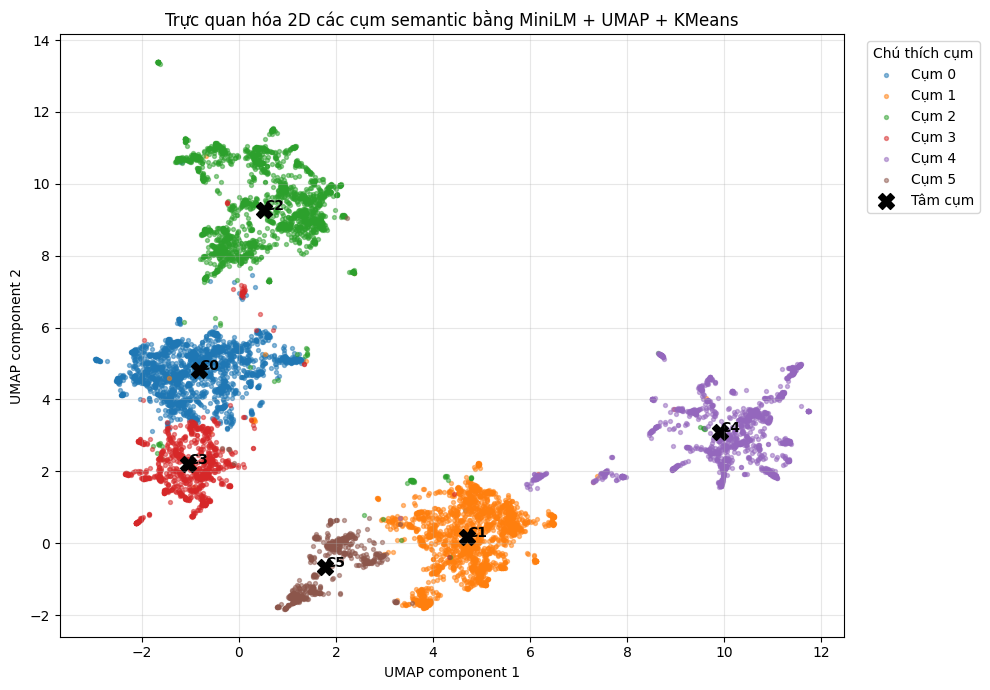

In [27]:
# Cell 14: Trực quan hóa 2D các cụm semantic baseline

start_time = time.time()

umap_2d = umap.UMAP(
    n_neighbors=15,
    n_components=2,
    min_dist=0.0,
    metric="cosine",
    random_state=RANDOM_STATE
)

X_minilm_2d = umap_2d.fit_transform(X_minilm_norm)

elapsed_time = time.time() - start_time
print(f"Hoàn thành UMAP 2D trong: {elapsed_time:.2f} giây")

plt.figure(figsize=(10, 7))

# Vẽ từng cụm riêng để legend hiển thị rõ màu nào là cụm nào
for cluster_id in sorted(np.unique(best_labels)):
    idx = best_labels == cluster_id

    plt.scatter(
        X_minilm_2d[idx, 0],
        X_minilm_2d[idx, 1],
        s=8,
        alpha=0.5,
        label=f"Cụm {cluster_id}"
    )

# Tính tâm cụm trong không gian trực quan 2D
centers_2d = []

for cluster_id in sorted(np.unique(best_labels)):
    idx = best_labels == cluster_id
    center = X_minilm_2d[idx].mean(axis=0)
    centers_2d.append(center)

centers_2d = np.array(centers_2d)

# Vẽ tâm cụm
plt.scatter(
    centers_2d[:, 0],
    centers_2d[:, 1],
    marker="X",
    s=130,
    c="black",
    label="Tâm cụm"
)

for i, center in enumerate(centers_2d):
    plt.text(
        center[0],
        center[1],
        f"C{i}",
        fontsize=10,
        weight="bold"
    )

plt.title("Trực quan hóa 2D các cụm semantic bằng MiniLM + UMAP + KMeans")
plt.xlabel("UMAP component 1")
plt.ylabel("UMAP component 2")
plt.grid(alpha=0.3)
plt.legend(title="Chú thích cụm", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [28]:
# Cell 15: Phân tích phân bố chuyên mục theo cụm MiniLM
# Cell này kiểm tra mỗi cụm semantic tương ứng chủ yếu với chuyên mục nào.

cluster_category_table = pd.crosstab(
    df_minilm_assignments["cluster_minilm"],
    df_minilm_assignments["category_clean"]
)

cluster_category_ratio = cluster_category_table.div(
    cluster_category_table.sum(axis=1),
    axis=0
)

print("Bảng số lượng chuyên mục trong từng cụm:")
display(cluster_category_table)

print("\nBảng tỷ lệ chuyên mục trong từng cụm:")
display(cluster_category_ratio.round(4))

cluster_summary = []

for cluster_id in sorted(df_minilm_assignments["cluster_minilm"].unique()):
    row_counts = cluster_category_table.loc[cluster_id]
    dominant_category = row_counts.idxmax()
    dominant_count = row_counts.max()
    cluster_size = row_counts.sum()
    cluster_purity = dominant_count / cluster_size

    cluster_summary.append({
        "cluster_minilm": cluster_id,
        "cluster_size": cluster_size,
        "dominant_category": dominant_category,
        "dominant_count": dominant_count,
        "cluster_purity": cluster_purity
    })

cluster_summary_df = pd.DataFrame(cluster_summary)

print("\nTóm tắt chuyên mục chiếm đa số theo cụm:")
display(cluster_summary_df)

Bảng số lượng chuyên mục trong từng cụm:


category_clean,cong_nghe,du_lich,giao_duc,suc_khoe,the_thao,xe
cluster_minilm,,,,,,
0,104,34,1704,21,9,3
1,40,1737,21,24,17,21
2,33,31,112,1804,20,2
3,774,20,54,63,10,14
4,3,64,35,12,1342,8
5,37,93,15,5,4,437



Bảng tỷ lệ chuyên mục trong từng cụm:


category_clean,cong_nghe,du_lich,giao_duc,suc_khoe,the_thao,xe
cluster_minilm,,,,,,
0,0.0555,0.0181,0.9088,0.0112,0.0048,0.0016
1,0.0215,0.9339,0.0113,0.0129,0.0091,0.0113
2,0.0165,0.0155,0.0559,0.9011,0.0100,0.0010
3,0.8278,0.0214,0.0578,0.0674,0.0107,0.0150
4,0.0020,0.0437,0.0239,0.0082,0.9167,0.0055
5,0.0626,0.1574,0.0254,0.0085,0.0068,0.7394



Tóm tắt chuyên mục chiếm đa số theo cụm:


,cluster_minilm,cluster_size,dominant_category,dominant_count,cluster_purity
0,0,1875,giao_duc,1704,0.908800
1,1,1860,du_lich,1737,0.933871
2,2,2002,suc_khoe,1804,0.901099
3,3,935,cong_nghe,774,0.827807
4,4,1464,the_thao,1342,0.916667
5,5,591,xe,437,0.739425


### Nhận xét phân bố chuyên mục theo cụm

Bảng chéo cho thấy các cụm MiniLM có độ thuần khá cao. Hầu hết các cụm đều có một chuyên mục chiếm đa số rõ rệt:

- Cụm 0 chủ yếu là `giao_duc`, chiếm khoảng 90.88%.
- Cụm 1 chủ yếu là `du_lich`, chiếm khoảng 93.39%.
- Cụm 2 chủ yếu là `suc_khoe`, chiếm khoảng 90.11%.
- Cụm 3 chủ yếu là `cong_nghe`, chiếm khoảng 82.78%.
- Cụm 4 chủ yếu là `the_thao`, chiếm khoảng 91.67%.
- Cụm 5 chủ yếu là `xe`, chiếm khoảng 73.94%.

Nhìn chung, mô hình MiniLM semantic baseline đã tạo được các cụm có khả năng tương ứng tốt với chuyên mục thật. Cụm `xe` có độ thuần thấp hơn các cụm còn lại, cho thấy nội dung xe có thể giao thoa với các chủ đề như du lịch hoặc công nghệ.

In [30]:
# Cell 16: Trích xuất từ khóa nổi bật cho từng cụm MiniLM
# Dùng TF-IDF trên lexical_text để diễn giải nội dung của từng cụm semantic.

from sklearn.feature_extraction.text import TfidfVectorizer

pd.set_option("display.max_colwidth", None)

# Gắn nhãn đại diện cho từng cụm dựa trên chuyên mục chiếm đa số
cluster_to_label = dict(
    zip(
        cluster_summary_df["cluster_minilm"],
        cluster_summary_df["dominant_category"]
    )
)

df_minilm_assignments["cluster_label"] = df_minilm_assignments["cluster_minilm"].map(cluster_to_label)

# Văn bản dùng để trích xuất keyword là lexical_text vì đã tách từ và loại stopwords
texts_for_keywords = df_work["lexical_text"].fillna("").astype(str)

tfidf_keyword_vectorizer = TfidfVectorizer(
    min_df=5,
    max_df=0.85,
    max_features=10000,
    token_pattern=r"(?u)\b[\w_]{2,}\b"
)

X_keyword_tfidf = tfidf_keyword_vectorizer.fit_transform(texts_for_keywords)
feature_names = np.array(tfidf_keyword_vectorizer.get_feature_names_out())

top_n = 15
cluster_keywords = []

for cluster_id in sorted(df_minilm_assignments["cluster_minilm"].unique()):
    cluster_indices = df_minilm_assignments.index[
        df_minilm_assignments["cluster_minilm"] == cluster_id
    ].tolist()

    cluster_tfidf = X_keyword_tfidf[cluster_indices]
    mean_tfidf = np.asarray(cluster_tfidf.mean(axis=0)).ravel()

    top_indices = mean_tfidf.argsort()[::-1][:top_n]
    top_keywords = feature_names[top_indices]

    cluster_info = cluster_summary_df[
        cluster_summary_df["cluster_minilm"] == cluster_id
    ].iloc[0]

    cluster_keywords.append({
        "cluster_minilm": cluster_id,
        "cluster_label": cluster_to_label.get(cluster_id, ""),
        "cluster_size": int(cluster_info["cluster_size"]),
        "cluster_purity": cluster_info["cluster_purity"],
        "top_keywords": ", ".join(top_keywords)
    })

minilm_cluster_keywords_df = pd.DataFrame(cluster_keywords)

print("Từ khóa nổi bật theo từng cụm MiniLM:")
display(minilm_cluster_keywords_df)

Từ khóa nổi bật theo từng cụm MiniLM:


,cluster_minilm,cluster_label,cluster_size,cluster_purity,top_keywords
0,0,giao_duc,1875,0.908800,"trường, học_sinh, giáo_dục, đại_học, thi, học, đào_tạo, sinh_viên, lớp, giáo_viên, em, tuyển_sinh, xét, thí_sinh, chương_trình"
1,1,du_lich,1860,0.933871,"du_lịch, khách, du_khách, biển, văn_hóa, điểm, quốc_tế, tết, ông, tỉnh, hoa, nghiệm, bay, trải, lễ_hội"
2,2,suc_khoe,2002,0.901099,"y_tế, bệnh_viện, bệnh, bác_sĩ, bệnh_nhân, điều_trị, thực_phẩm, khám, sức_khỏe, ăn, thuốc, ung_thư, có_thể, ca, cơ_sở"
3,3,cong_nghe,935,0.827807,"ai, dùng, công_nghệ, mạng, dữ_liệu, có_thể, số, ông, ứng_dụng, google, thông_tin, công_ty, nền_tảng, hệ_thống, doanh_nghiệp"
4,4,the_thao,1464,0.916667,"đội, trận, giải, nữ, clb, cầu_thủ, hlv, bóng, tuyển, bóng_đá, thắng, thi_đấu, trận_đấu, malaysia, vòng"
5,5,xe,591,0.739425,"xe, điện, giao_thông, mẫu, tài_xế, ô_tô, cảnh_sát, đồng, giá, pin, sạc, triệu, chiếc, xăng, lái"


In [34]:
# Cell 17: Lưu output cần thiết

# 1. Lưu bảng kết quả ablation MiniLM
ablation_results_df.to_csv(
    OUTPUT_MINILM_ABLATION_RESULTS,
    index=False,
    encoding="utf-8-sig"
)

# 2. Lưu cấu hình MiniLM semantic baseline chính
best_minilm_config = {
    "model_name": "MiniLM_UMAP",
    "reduction": BEST_REDUCTION,
    "n_components": BEST_N_COMPONENTS,
    "k": BEST_K,
    "seed": BEST_SEED,
    "silhouette": float(best_result["silhouette"]),
    "dbi": float(best_result["dbi"]),
    "ch": float(best_result["ch"]),
    "ari": float(best_result["ari"]),
    "nmi": float(best_result["nmi"]),
    "purity": float(best_result["purity"])
}

with open(OUTPUT_BEST_MINILM_CONFIG, "w", encoding="utf-8") as f:
    json.dump(best_minilm_config, f, ensure_ascii=False, indent=4)

# 3. Lưu nhãn cụm MiniLM để Notebook 5 và Notebook 6 dùng lại
df_minilm_assignments[
    ["doc_id", "category_clean", "cluster_minilm", "cluster_label"]
].to_csv(
    OUTPUT_MINILM_ASSIGNMENTS,
    index=False,
    encoding="utf-8-sig"
)

print("Đã lưu các output cần thiết của Notebook 4:")
print("1.", OUTPUT_MINILM_ABLATION_RESULTS)
print("2.", OUTPUT_BEST_MINILM_CONFIG)
print("3.", OUTPUT_MINILM_ASSIGNMENTS)
print("\nEmbedding MiniLM đã được lưu từ Cell 5 tại:")
print(OUTPUT_MINILM_EMBEDDINGS)

Đã lưu các output cần thiết của Notebook 4:
1. /content/drive/MyDrive/PROJECT/outputs/results/minilm_ablation_results.csv
2. /content/drive/MyDrive/PROJECT/outputs/results/best_minilm_config.json
3. /content/drive/MyDrive/PROJECT/outputs/assignments/minilm_cluster_assignments.csv

Embedding MiniLM đã được lưu từ Cell 5 tại:
/content/drive/MyDrive/PROJECT/outputs/features/minilm_embeddings.npy
